# Generate Disturbance Profile


In [69]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/test_cases


In [ ]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

import new file (pls pls work)

In [34]:
case_path = andes.get_case(test_case_dir / "gen_disturbance_profile.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)


,gen_idx,bus,M
0,GENROU_2,2,4.0
1,GENROU_3,3,4.0


## Set Up Fault and Run TDS
Trip the synchronous generator with the highest inertia (GENROU 2) at t = 1s.  $\alpha$ (inertia scaling) set to lowest (0.15). 

In [41]:
add_idx = "PQ_3" # add a load, causing a disturbance

# inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15] just testing lowest
# alpha = 0.15

ss = andes.load(case_path, setup=False)
ss.add("Toggle", model="PQ", dev=add_idx, t=1.0) # add the load @ t=1s
ss.setup()
ss.config.warn_abnormal = 0
ss.GENROU.M.v[:] = M_base

ss.PFlow.run()
ss.TDS.config.tf = 15
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0 # ignore stability criteria (run until end of simulation time)

ss.TDS.run()

results = ss.TDS.get_timeseries(ss.GENROU.omega)

## Results

### COI Frequency

           GENROU_2  GENROU_3
0.000000   1.000000  1.000000
0.033333   1.000000  1.000000
0.066667   1.000000  1.000000
0.100000   1.000000  1.000000
0.133333   1.000000  1.000000
...             ...       ...
14.866767  0.999998  0.999999
14.900100  0.999998  0.999998
14.933433  0.999998  0.999998
14.966767  0.999998  0.999998
15.000000  0.999998  0.999998

[453 rows x 2 columns]


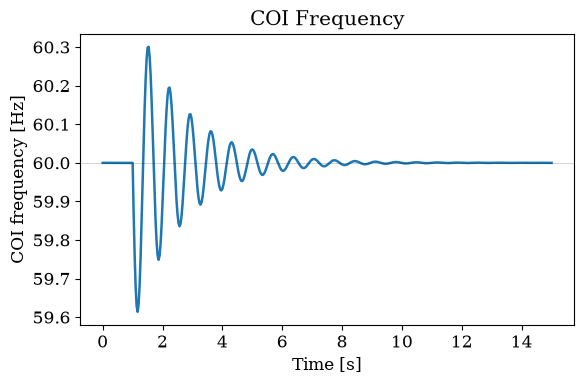

In [73]:
# plotting
weights = M_base / M_base.sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

print(results)

f_coi = (results.values * weights).sum(axis=1) * 60
ax.plot(results.index, f_coi, color="tab:blue", linewidth=1.8)

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("COI Frequency")
#ax.set_xlim(0.0, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

### Nadir & RoCoF

In [43]:
f_coi = (results.values * weights).sum(axis=1) * 60
t = results.index.values

nadir = f_coi[t > 1.0].min()

post = (t >= 1.0) & (t <= 2.0)
t_post, f_post = t[post], f_coi[post]
rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

print("Nadir: " + str(nadir))
print ("RoCoF: " + str(rocof))

Nadir: 59.613899192241064
RoCoF: 3.9133727148041566


### Voltages

In [44]:
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (453, 5)
Columns (bus indices): [1, 2, 3, 4, 0]


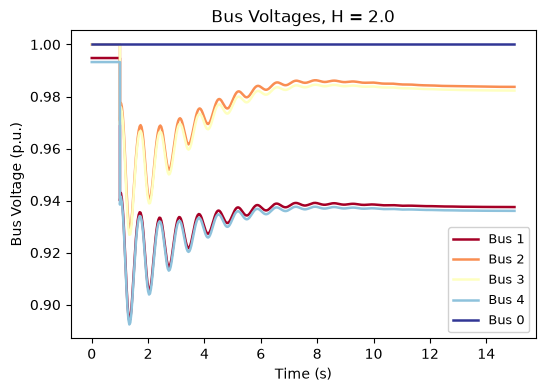

In [45]:
# Voltage at All Buses
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, bus in enumerate(voltage_df.columns):
    color = cmap(i / (len(voltage_df.columns) - 1))

    ax.plot(voltage_df.index, voltage_df[bus], color=color, linewidth=1.8,
            label=f"Bus {bus}")

H = np.average(M_base) / 2

ax.set_xlabel("Time (s)")
ax.set_ylabel("Bus Voltage (p.u.)")
ax.set_title(f"Bus Voltages, H = {H}")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


In [63]:
freq_1 = ss.TDS.get_timeseries(ss.BusFreq.f).loc[:,"BusFreq_1"]
angle_1 = ss.TDS.get_timeseries(ss.BusFreq.a).loc[:,"BusFreq_1"]
voltage_1 = voltage_df.loc[:,1]

0.000000     0.994801
0.033333     0.994801
0.066667     0.994801
0.100000     0.994801
0.133333     0.994801
               ...   
14.866767    0.937535
14.900100    0.937532
14.933433    0.937529
14.966767    0.937526
15.000000    0.937523
Name: 1, Length: 453, dtype: float64

In [66]:
## Export Bus 1 Voltage and Frequency
export_df = pd.concat([voltage_1, freq_1], axis=1)
export_df.columns = ["Voltage", "Frequency"]
export_df.index.name = "Time"
export_df

,Voltage,Frequency
Time,,
0.000000,0.994801,1.000000
0.033333,0.994801,1.000000
0.066667,0.994801,1.000000
0.100000,0.994801,1.000000
0.133333,0.994801,1.000000
...,...,...
14.866767,0.937535,1.000000
14.900100,0.937532,0.999999
14.933433,0.937529,0.999999


In [76]:
sim_time = ss.TDS.config.tf
export_df.to_excel(f'{disturbance_profile_dir}/disturbance_profile_{sim_time}.xlsx', index=True)